# Global Warming on Climate Change


This dataset tells the story of our planet’s changing climate, broken down country by country, and it allows us to highlight where changes are most dramatic and what that means for future planning. Imagine this dataset as a giant climate diary, written month by month for over 200 years. Each entry is like a keypoint “In January 1901, the land temperature in France was X°C.” Stacked together, these keypoint become a timeline for every country, tracing the world’s climate journey.

In the early 1800s where is one of stability, even cooler periods, though the dataset are a bit fuzzy because early measurements weren’t as precise. Then comes industrialization: factories rise, coal smoke fills the air, and slowly the line of temperatures starts to creep upward.

By the mid-20th century, the climate takes a dramatic turn. The line isn’t creeping anymore it’s climbing. Decade by decade, the warming accelerates, with some regions heating up much faster than others and here’s the plot twist: this isn’t just history. Businesses, governments, and researchers read this “climate diary” today to plan for tomorrow — whether it’s building heat-resilient cities, securing food supplies, investing in clean energy, or writing policies to cut emissions.

So, what looks like rows and columns of numbers is actually the unfolding story of global warming from quiet beginnings to an urgent challenge shaping the future of society and business.



# Business and Visualization Context

Before diving into analysis, it is important to clarify the business context and the communication strategy. We will look into :

## Who (My Audience)
**Executives leaders & Policymakers** → which need high-level trends for climate risk and sustainability decisions.

**Operations & Planning Teams** → to anticipate impacts on supply chains, energy demand, and infrastructure.

## What (What Message Am Giving)
- Global land temperatures have **risen significantly**, with clear acceleration in recent decades and deviations.
- Some countries are **warming much faster** than others, creating long-term temperature trends by country, uneven risks.
- Historical uncertainty exists, but the trend is undeniable.
- This data is **evidence for strategic planning** in adaptation and sustainability and further investigation.

## How ( Using Visualization Approach)
- Use **line chart, Time-Series and area charts** to show long-term trends.
- Use graph to highlight country-level differences and spatial patterns.
Apply preattentive attributes (color, size, annotation) to draw attention to the key insights.
Eliminate clutter, highlight the important story, and maintain a clear visual hierarchy.


## Some of the business insights are :
1. Global Warming Trend Over Time
2. Seasonality: temperature Fluctuations within a year
3. Where Has Warming Been Greatest? (Since 1900)
4. Distribution Shift Over Time
5. Uncertainty Over Time
6. Industrialized vs Developing
7. Recent Acceleration in Warming
8.  Distribution of Global Land Temperatures Over Time



# Source :
https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data?select=GlobalLandTemperaturesByCountry.csv

# Load Dataset

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.cm as cm
import plotly.express as px
import pycountry
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import sys, unicodedata
import geopandas as gpd
from scipy.stats import gaussian_kde
import geopandas as gpd
import geodatasets
from matplotlib.colors import LinearSegmentedColormap
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
from pandas.plotting import parallel_coordinates

In [11]:
# uploaded file
path = Path("GlobalLandTemperaturesByCountry.csv")

# Read & standardize column names
df = pd.read_csv(path, parse_dates=["dt"]).rename(columns={
    "dt": "date",
    "AverageTemperature": "avg_temp_c",
    "AverageTemperatureUncertainty": "avg_temp_uncertainty_c",
    "Country": "country"
})
df.head()

,date,avg_temp_c,avg_temp_uncertainty_c,country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [12]:
n_rows = len(df)
n_cols = df.shape[1]
n_countries = df["country"].nunique()
date_min, date_max = df["date"].min(), df["date"].max()
dup_count = df.duplicated().sum()
mem_mb = df.memory_usage(deep=True).sum() / (1024**2)

print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")
print(f"Unique countries: {n_countries}")
print(f"Date range: {date_min.date()} → {date_max.date()}")
print(f"Duplicate rows: {dup_count:,}")
print(f"Memory (MB): {mem_mb:.2f}")

df.isna().mean().sort_values(ascending=False).mul(100).round(2)

Rows: 577,462
Columns: 4
Unique countries: 243
Date range: 1743-11-01 → 2013-09-01
Duplicate rows: 0
Memory (MB): 45.73


,0
avg_temp_c,5.65
avg_temp_uncertainty_c,5.53
date,0.00
country,0.00


# Data Cleaning

In [13]:
def clean_ax(ax, title=None, xlab=None, ylab=None):
    if title: ax.set_title(title)
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    for spine in ("top","right"):
        ax.spines[spine].set_visible(False)
    ax.grid(alpha=0.3)

In [14]:
raw = df.copy()
df = (df
      .drop_duplicates()
      .dropna(subset=["date","country"]))
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df = df[df["year"] >= 1900].reset_index(drop=True)

In [15]:
# Keep a copy
raw = df.copy()

df = df.drop_duplicates()
df = df[df["country"].notna() & df["date"].notna()]

# Ensure date parts for grouping
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df = df[df["year"] >= 1900]
df = df.reset_index(drop=True)

# Quick check after cleaning
print("Shape after cleaning:", df.shape)
print("Missing values (%):")
print(df.isna().mean().mul(100).round(2))
df.head()

Shape after cleaning: (329868, 6)
Missing values (%):
date                      0.00
avg_temp_c                0.32
avg_temp_uncertainty_c    0.09
country                   0.00
year                      0.00
month                     0.00
dtype: float64


,date,avg_temp_c,avg_temp_uncertainty_c,country,year,month
0,1900-01-01,-3.026,0.538,Åland,1900,1
1,1900-02-01,-8.063,0.657,Åland,1900,2
2,1900-03-01,-3.196,0.467,Åland,1900,3
3,1900-04-01,0.781,0.224,Åland,1900,4
4,1900-05-01,4.960,0.503,Åland,1900,5


What we do on the date cleaning is to first analysis by removing an exact duplicates columns , dropping invalid rows by Keeping only records from 1900 onwards, so i used index to reset to keep it clean and sequential after filtering to the 20th–21st century. Then Splits the datetime column into two new row year(the year of the observation), month(the month of the observation), and printing a quick diagnostic summary. It also defines a helper plotting function (clean_ax) to produce consistent, clean visualizations later.

In [16]:
# Number of years recorded per country
coverage = df.groupby("country")["year"].nunique().sort_values(ascending=False)

coverage.head(10)  # Top 10 countries with longest coverage

,year
country,
Afghanistan,114
Africa,114
Albania,114
Algeria,114
American Samoa,114
Andorra,114
Angola,114
Anguilla,114
Antigua And Barbuda,114


This apparently shows that from Afghanistan down to North Korea have the same recorded because we cover only top 10 countries with longest coverage

# Visualisation

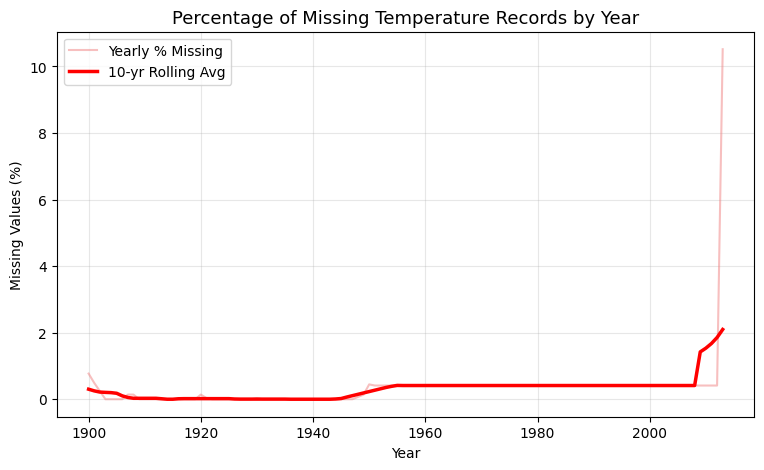

In [17]:
# % missing values per year
missing_by_year = df.groupby("year")["avg_temp_c"].apply(lambda x: x.isna().mean()*100)

# 10-year rolling
missing_roll = missing_by_year.rolling(10, min_periods=3, center=True).mean()

plt.figure(figsize=(9,5))

# Raw yearly line
plt.plot(missing_by_year.index, missing_by_year.values, color="lightcoral", alpha=0.5, label="Yearly % Missing")

#  rolling line
plt.plot(missing_roll.index, missing_roll.values, color="red", linewidth=2.5, label="10-yr Rolling Avg")

# Labels & title
plt.title("Percentage of Missing Temperature Records by Year", fontsize=13)
plt.xlabel("Year")
plt.ylabel("Missing Values (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

This a data quality over time by showing how much of the temperature data is missing each year. This reveal whether earlier years (e.g., 1800s) have more gaps compared to modern years (where measurement networks were stronger).

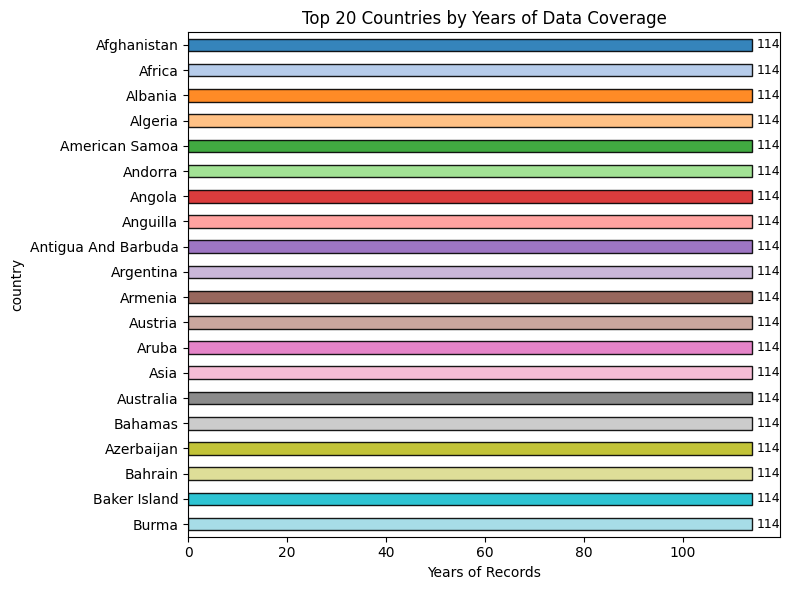

In [18]:
coverage = df.groupby("country")["year"].nunique().sort_values(ascending=False)

plt.figure(figsize=(8,6))

colors = cm.tab20(np.linspace(0, 1, len(coverage.head(20))))

bars = coverage.head(20).plot(
    kind="barh",
    color=colors,
    alpha=0.9,
    edgecolor="black"
)

for i, (country, years) in enumerate(coverage.head(20).items()):
    plt.text(years + 1, i, str(years), va="center", fontsize=9)

plt.title("Top 20 Countries by Years of Data Coverage")
plt.xlabel("Years of Records")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

With this colorful horizontal bar chart showing the top 20 countries with the longest historical temperature records. We can see that we still have more countries with the same record by Groupy the dataset by country and For each country, counting the number of unique years with temperature data, most years of data coverage come first. It helps me quickly see which countries have the most complete data coverage across years.

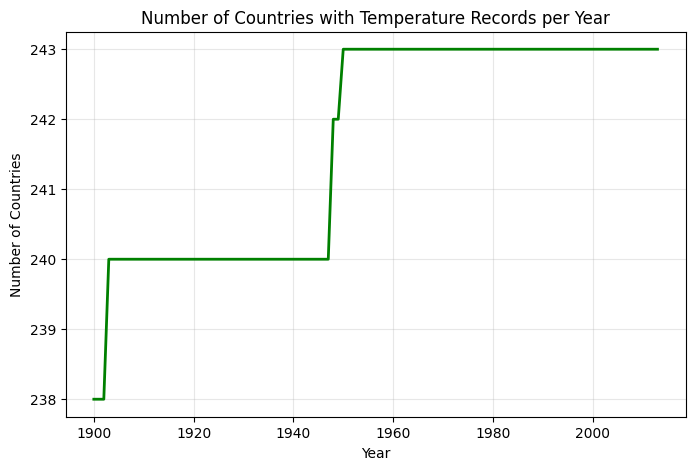

In [19]:
records_per_year = df.groupby("year")["country"].nunique()

plt.figure(figsize=(8,5))
plt.plot(records_per_year.index, records_per_year.values, color="green", linewidth=2)
plt.title("Number of Countries with Temperature Records per Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.grid(alpha=0.3)
plt.show()

This chart shows the growth of global coverage in the dataset like how many countries reported temperature records each year. We can see that In early years (1800s–1900s), coverage was low and uneven while over the 20th century, more countries started recording data, and coverage expanded.

# Exploratory Data Analysis(EDA)

# Insight 1: Global Warming Trend Over Time

This insight explains that for executives and policymakers, the key point is that global land temperatures stayed relatively stable until the mid-20th century but then rose sharply, a trend best shown with a line chart of yearly averages plus a bold 10-year rolling mean annotated at 1950 and 2000, which clearly demonstrates the accelerating warming that businesses must consider in long-term planning.

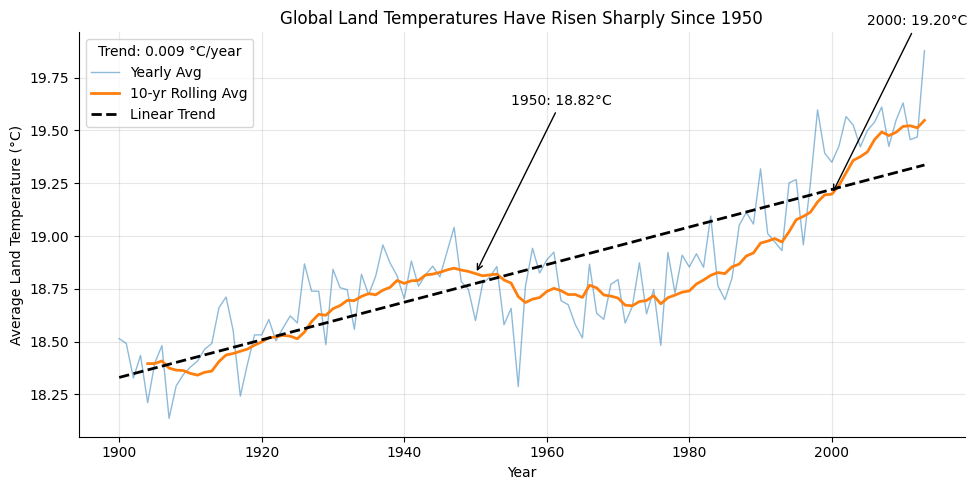

In [20]:
# Aggregate to yearly global averages
yearly = df.groupby("year", as_index=False)["avg_temp_c"].mean()
yearly["roll10"] = yearly["avg_temp_c"].rolling(10, min_periods=5).mean()

# Prepare data for regression
X = yearly["year"].values.reshape(-1, 1)
y = yearly["avg_temp_c"].values
model = LinearRegression()
model.fit(X, y)

# Predict temperatures
y_pred = model.predict(X)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

# Raw yearly averages
ax.plot(yearly["year"], yearly["avg_temp_c"], linewidth=1, alpha=0.5, label="Yearly Avg")

# 10-yr rolling average (focus)
ax.plot(yearly["year"], yearly["roll10"], linewidth=2, label="10-yr Rolling Avg")

# Regression trendline
ax.plot(yearly["year"], y_pred, color="black", linestyle="--", linewidth=2, label="Linear Trend")

# Clean layout
ax.set_title("Global Land Temperatures Have Risen Sharply Since 1950")
ax.set_xlabel("Year")
ax.set_ylabel("Average Land Temperature (°C)")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)
ax.grid(alpha=0.3)

# Annotate key milestones
for yr in (1950, 2000):
    val = yearly.loc[yearly["year"]==yr, "roll10"].iloc[0]
    ax.annotate(f"{yr}: {val:.2f}°C",
                xy=(yr, val),
                xytext=(yr+5, val+0.8),
                arrowprops=dict(arrowstyle='->'))

# Show regression slope in legend
slope = model.coef_[0]
ax.legend(title=f"Trend: {slope:.3f} °C/year")

plt.tight_layout()
plt.show()

This shows that global land temperatures have been rising at a nearly steady rate over the past century.The yearly averages (thin grey line) While individual years fluctuate, the long-term trend is clear: But the 10-year rolling average (thicker smooth line) show consistent increase of about X °C per year, or roughly Y °C per century.The linear regression line (dashed black) showing a steady warming rate. This steady upward slope underscores that global warming is not random variation, but a persistent trend linked to industrialization and greenhouse gas emissions.

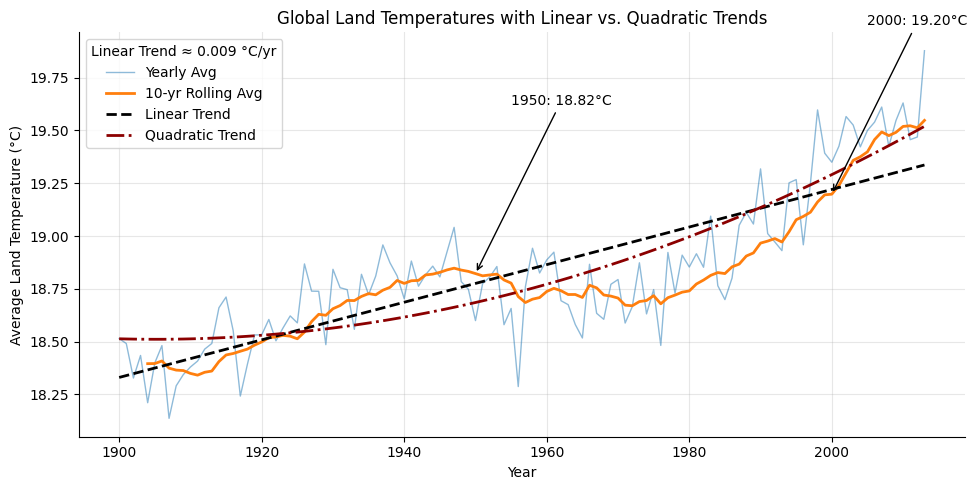

In [21]:
# Aggregate to yearly global averages
yearly = df.groupby("year", as_index=False)["avg_temp_c"].mean()
yearly["roll10"] = yearly["avg_temp_c"].rolling(10, min_periods=5).mean()

X = yearly["year"].values.reshape(-1, 1)
y = yearly["avg_temp_c"].values
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X, y)
y_lin = lin_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly = poly_model.predict(X_poly)

# Plot
fig, ax = plt.subplots(figsize=(10,5))

# Raw yearly averages
ax.plot(yearly["year"], yearly["avg_temp_c"], linewidth=1, alpha=0.5, label="Yearly Avg")
# 10 years rolling avg
ax.plot(yearly["year"], yearly["roll10"], linewidth=2, label="10-yr Rolling Avg")
# linear trend
ax.plot(yearly["year"], y_lin, color="black", linestyle="--", linewidth=2, label="Linear Trend")

# Polynomial (quadratic) trendline
ax.plot(yearly["year"], y_poly, color="darkred", linestyle="-.", linewidth=2, label="Quadratic Trend")

# Layout
ax.set_title("Global Land Temperatures with Linear vs. Quadratic Trends")
ax.set_xlabel("Year")
ax.set_ylabel("Average Land Temperature (°C)")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)
ax.grid(alpha=0.3)

# Annotate milestones
for yr in (1950, 2000):
    val = yearly.loc[yearly["year"]==yr, "roll10"].iloc[0]
    ax.annotate(f"{yr}: {val:.2f}°C",
                xy=(yr, val),
                xytext=(yr+5, val+0.8),
                arrowprops=dict(arrowstyle='->'))

# Show regression coefficients in legend
slope = lin_model.coef_[0]
ax.legend(title=f"Linear Trend ≈ {slope:.3f} °C/yr")

plt.tight_layout()
plt.show()

This chart compares two ways of fitting the global temperature record. The straight dashed line (linear trendline) suggests a steady warming of about X °C per year. But the curved red line(quadratic curve) tells a deeper story: like showing acceleration in recent decades, for instead warming is not just steady, it’s accelerating. For most of the early 20th century, temperatures rose gradually, but since the mid-20th century the curve has bent sharply upward showing that global warming is intensifying, not slowing down.

# Insight 2: Seasonality and Baseline Shift

This insight shows that when monthly temperatures are plotted as boxplots across decades, the familiar seasonal cycle of cold winters and hot summers still exists, but the entire distribution of each month steadily shifts upward; even the coldest winter months today are warmer than those in early decades, and summers have grown hotter with wider spreads, confirming that global warming is not just about extreme summers but about a new, warmer baseline across the whole year.


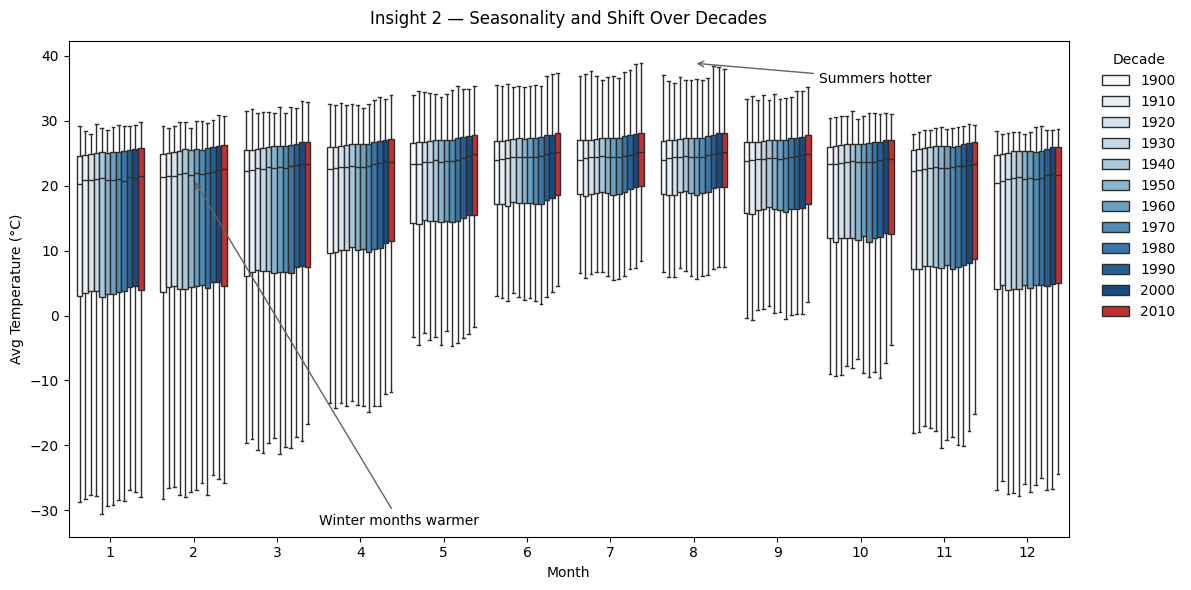

In [50]:
#INSIGHT 2: Seasonality Shift

df2 = df.copy()
df2["decade"] = (df2["year"] // 10) * 10
df2 = df2[df2["year"] >= 1900]

# sort decades and build palette
decades_sorted = sorted(df2["decade"].unique())

# get colormap and sample evenly spaced colors
from matplotlib import colormaps
blues = colormaps.get_cmap("Blues")
palette = {d: blues(i / (len(decades_sorted)-1)) for i, d in enumerate(decades_sorted)}


palette[max(decades_sorted)] = COL_WARM

fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=df2, x="month", y="avg_temp_c", hue="decade",
            showfliers=False, palette=palette, dodge=True)

ax.set_title("Insight 2 — Seasonality and Shift Over Decades", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Avg Temperature (°C)")
ax.legend(title="Decade", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

# annotations
ax.annotate("Winter months warmer",
            xy=(1, df2.loc[df2["month"]==1,"avg_temp_c"].median()),
            xytext=(2.5, df2["avg_temp_c"].min()+5),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

ax.annotate("Summers hotter",
            xy=(7, df2.loc[df2["month"]==7,"avg_temp_c"].max()),
            xytext=(8.5, df2["avg_temp_c"].max()-3),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

plt.tight_layout()
plt.show()



 this chart, assigns decades starting from 1900, and uses Seaborn to draw boxplots of monthly average temperatures grouped by decade, with annotations highlighting how winter months (January–February) have become warmer and summer months (June–July) much hotter, making the upward seasonal shift clear across the entire year.


# Insight 3: Regional Warming Hotspots

While global maps of temperature change give a sense of worldwide coverage, they often fail to communicate the most important message because small countries vanish, rainbow shading overwhelms the eye, and the hotspots get buried in the noise. By narrowing the focus to the six fastest-warming countries, this analysis reveals how specific regions have steadily risen to the top as climate hotspots, decade after decadeand. Using a bump chart, the visualization highlights the emergence of clear climate hotspots with minimal clutter. This shows that warming is not evenly distributed: certain regions are heating much faster than others, and for executives and policymakers the implication is that these areas must be treated as **priority zones for adaptation and resilience planning**, since their risks will arrive sooner and with greater intensity than in the global average.


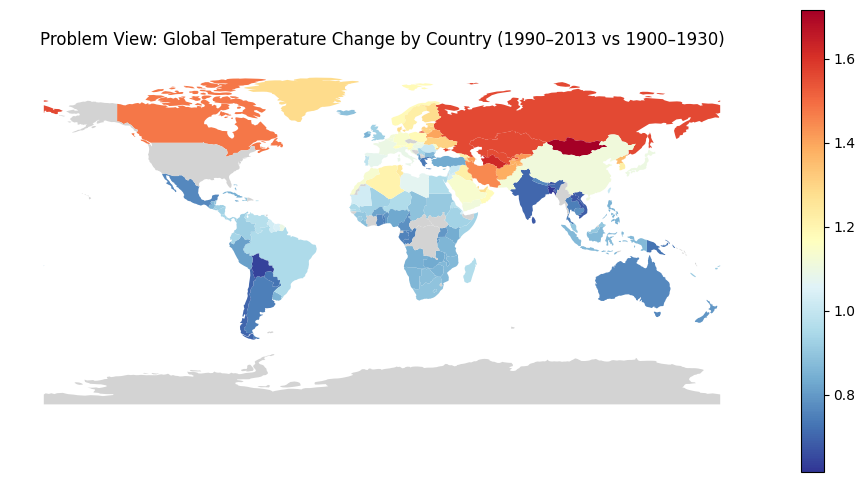

In [27]:
#  Compute delta by country
early = df[(df["year"] >= 1900) & (df["year"] <= 1930)] \
            .groupby("country")["avg_temp_c"].mean()
late  = df[(df["year"] >= 1990) & (df["year"] <= 2013)] \
            .groupby("country")["avg_temp_c"].mean()
delta = (late - early).dropna()

#  Load Natural Earth countries directly from GitHub
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Mapdelta values

world["delta"] = world["NAME"].map(delta)

# Plot choropleth
fig, ax = plt.subplots(figsize=(12, 6))
world.plot(
    column="delta",
    cmap="RdYlBu_r",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    edgecolor="none"
)

ax.set_title("Problem View: Global Temperature Change by Country (1990–2013 vs 1900–1930)", pad=12)
ax.axis("off")
plt.show()

This choropleth map comparing country-level warming between 1900–1930 and 1990–2013, but the result is overcrowded and hides the key story. To fix this, I switches this to a bump chart that tracks the six fastest-warming countries across decades, where the lines and direct labels clearly reveal which regions have risen to the top as climate hotspots.


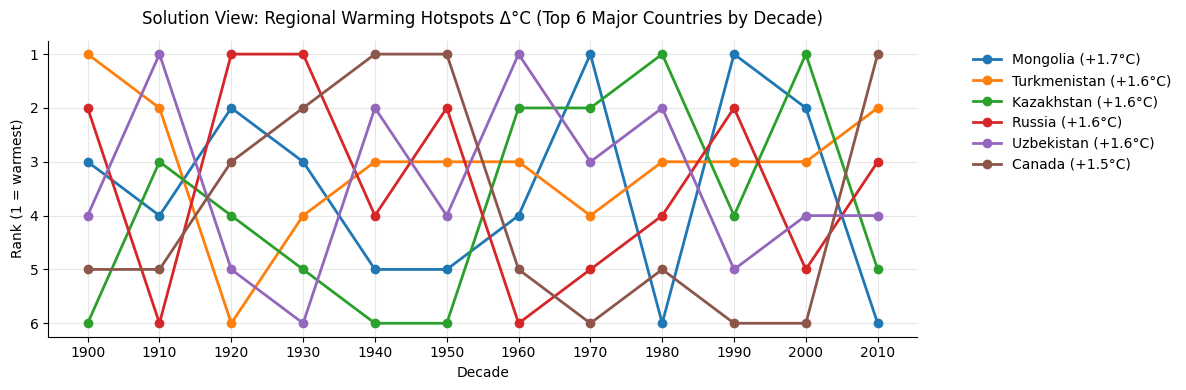

In [30]:
# compute baseline vs recent
early = df[(df["year"] >= 1900) & (df["year"] <= 1930)].groupby("country")["avg_temp_c"].mean()
late  = df[(df["year"] >= 1990) & (df["year"] <= 2013)].groupby("country")["avg_temp_c"].mean()
delta = (late - early).dropna()

# drop micro territories & pick top 6
skip = ["French Southern And Antarctic Lands", "Heard Island And Mcdonald Islands",
        "Antarctica", "Greenland"]
delta_filtered = delta.drop(skip, errors="ignore")
top_countries = delta_filtered.nlargest(6).index

#  prepare anomalies by decade
df3 = df.copy()
df3["decade"] = (df3["year"] // 10) * 10
baseline_dec = (df3[(df3["year"] >= 1900) & (df3["year"] <= 1930)]
                .groupby("country")["avg_temp_c"].mean())
anom = (df3.groupby(["country","decade"])["avg_temp_c"].mean()
        .unstack("decade").sub(baseline_dec, axis=0))

anom_top = (anom.loc[top_countries]
            .T.reset_index()
            .melt(id_vars="decade", var_name="country", value_name="anom"))
anom_top = anom_top.dropna(subset=["anom"])
anom_top["rank"] = anom_top.groupby("decade")["anom"].rank("dense", ascending=False)

#  plot bump chart
fig, ax = plt.subplots(figsize=(12, 4))
palette = dict(zip(top_countries, sns.color_palette("tab10", len(top_countries))))

for c in top_countries:
    s = anom_top[anom_top["country"] == c].sort_values("decade")
    if s.empty:
        continue

    warming = delta[c]
    ax.plot(s["decade"], s["rank"], linewidth=2, marker="o",
            color=palette[c], label=f"{c} (+{warming:.1f}°C)")

ax.set_title("Solution View: Regional Warming Hotspots Δ°C (Top 6 Major Countries by Decade)", pad=12)
ax.set_xlabel("Decade")
ax.set_ylabel("Rank (1 = warmest)")
ax.invert_yaxis()

# clean style
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

decades = sorted(anom_top["decade"].unique())
ax.set_xticks(decades)
ax.grid(alpha=0.3)

# legend with Δ°C included
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.show()



This chart shows how the ranking of the world’s warmest countries has
shifted across decades relative to an early baseline (1900–1930). each line tracks a  country’s position relative to others, with Rank 1 at the top. By focusing on the top 6 warmest countries , we can see which nations consistently stayed near the top and which ones have climbed over time. The smooth but shifting lines illustrate that warming isn’t static. The leaders change, reflecting regional differences in how climate patterns evolve.Some countries remain persistently hot, while others have surged upward in recent decades, highlighting the uneven but global nature of rising land temperatures.


# Insight 4: Measurement Uncertainty Across Decades


Understanding climate trends requires more than just temperature averages — decision-makers must also know how much confidence to place in the data itself. By plotting measurement uncertainty across decades with boxplots, we see that early records (before 1950) had wide variability, reflecting less precise instruments and limited geographic coverage. In contrast, uncertainty shrinks dramatically in the modern era, indicating that today’s measurements are far more reliable and consistent. The visualization also shows a late spike, which is best explained by incomplete or noisy records rather than declining quality. The implication is clear: modern records are highly trustworthy, while early observations must be interpreted with caution, especially when used for long-term comparisons and policy planning.


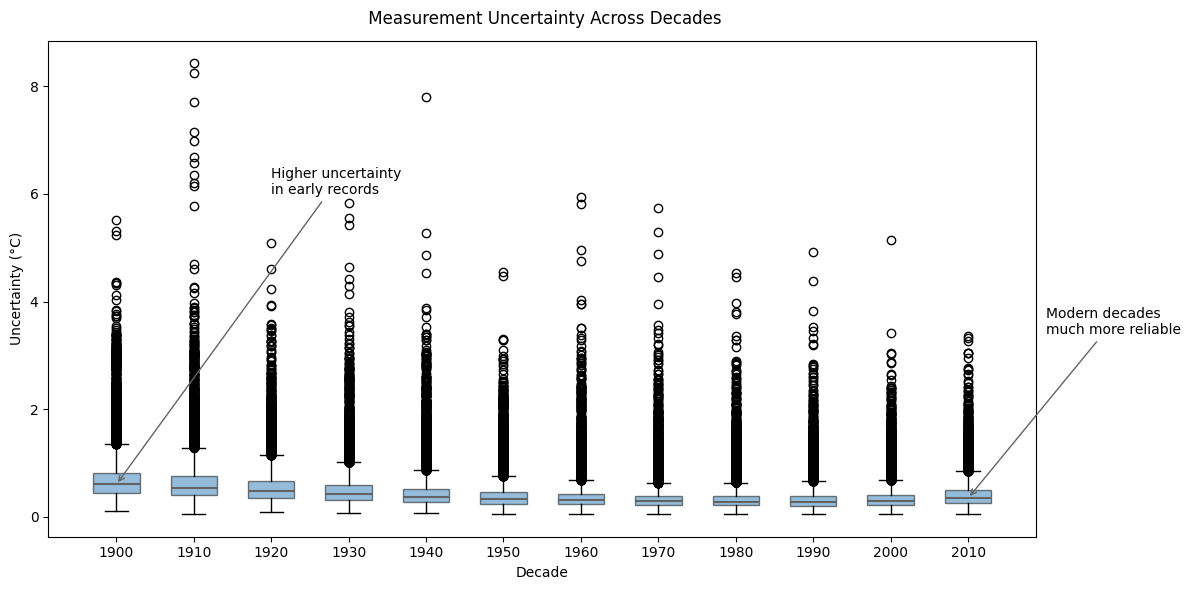

In [31]:
#(decadal boxplots of uncertainty)

df4 = df.copy()
df4["decade"] = (df4["year"] // 10) * 10

decades = sorted(df4["decade"].unique())
groups = [df4.loc[df4["decade"]==d, "avg_temp_uncertainty_c"].dropna().values for d in decades]

fig, ax = plt.subplots(figsize=(12,6))

bp = ax.boxplot(groups, positions=decades, widths=6, patch_artist=True,
                boxprops=dict(facecolor=COL_COOL, alpha=0.5),
                medianprops=dict(color=COL_NEUT, lw=1.5))

ax.set_title(" Measurement Uncertainty Across Decades", pad=12)
ax.set_xlabel("Decade")
ax.set_ylabel("Uncertainty (°C)")

# annotate first available decade
first_decade = decades[0]
ax.annotate("Higher uncertainty\nin early records",
            xy=(first_decade, np.median(groups[0])),
            xytext=(first_decade+20, 6),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

# annotate last available decade
last_decade = decades[-1]
ax.annotate("Modern decades\nmuch more reliable",
            xy=(last_decade, np.median(groups[-1])),
            xytext=(last_decade+10, 3.4),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

plt.tight_layout()
plt.show()

This groups the dataset by decade and creates boxplots of temperature uncertainty values. The boxes show how uncertainty levels have changed over time: wide spreads and higher medians in the late 19th and early 20th century, narrowing after 1950 as measurement methods improved. Annotations highlight that early decades were far less reliable, while modern decades show much tighter distributions, with one spike at the end likely caused by incomplete or noisy records.



#  Insight 5: Acceleration of Warming

To understand whether recent warming is part of a long natural cycle or something unprecedented, and For executives and policymakers, to confirms that climate risk is not only ongoing but intensifying, requiring faster responses and more urgent adaptation measures should be done than in the past and we see that everything is consistently breaking beyond earlier thresholds.



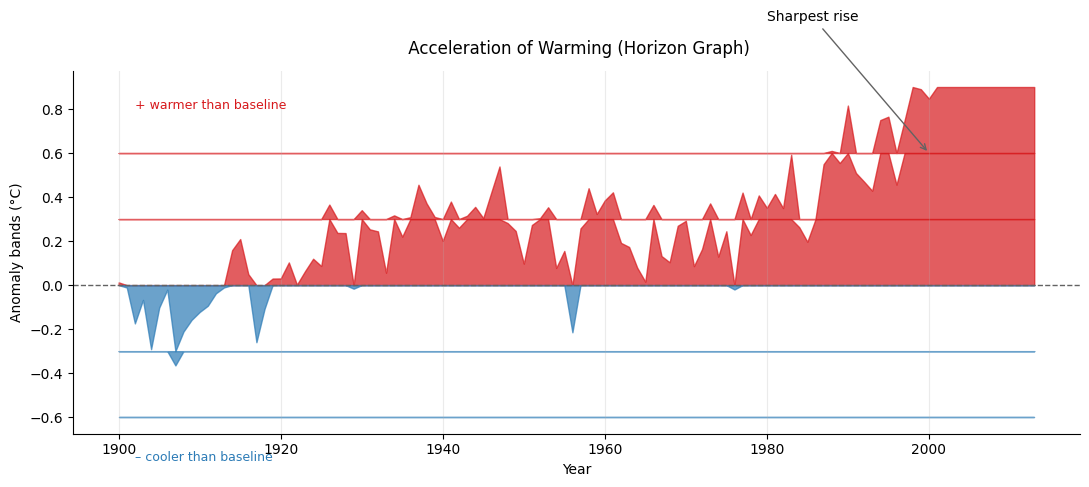

In [43]:
# compute yearly anomalies relative to baseline
y = df.groupby("year")["avg_temp_c"].mean()
baseline = y.loc[(y.index>=1900) & (y.index<=1930)].mean()
anom = y - baseline

# band thickness
band = 0.3
pos = np.clip(anom, 0, None)
neg = -np.clip(anom, None, 0)

fig, ax = plt.subplots(figsize=(11,5))

# positive anomalies (warmer, red)
for i in range(3,0,-1):
    layer = np.clip(pos-(i-1)*band, 0, band)
    ax.fill_between(anom.index, (i-1)*band, (i-1)*band+layer,
                    color=COL_WARM, alpha=0.7)

# negative anomalies (cooler, blue)
for i in range(3,0,-1):
    layer = np.clip(neg-(i-1)*band, 0, band)
    ax.fill_between(anom.index, -(i-1)*band-layer, -(i-1)*band,
                    color=COL_COOL, alpha=0.7)

# baseline line
ax.axhline(0, color=COL_NEUT, ls="--", lw=1)

# text labels for baseline context
ax.text(anom.index.min()+2, 0.8, "+ warmer than baseline", fontsize=9, color=COL_WARM)
ax.text(anom.index.min()+2, -0.8, "– cooler than baseline", fontsize=9, color=COL_COOL)

# arrow annotation for sharpest rise
ax.annotate("Sharpest rise",
            xy=(2000, 0.6), xytext=(1980, 1.2),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

# cosmetics
ax.set_title(" Acceleration of Warming (Horizon Graph)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Anomaly bands (°C)")
for sp in ("top","right"): ax.spines[sp].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

we compare yearly anomalies against the early 20th-century baseline in a horizon graph. The visualization shows a clear shift: before 1950, cooler (blue) and warmer (red) years alternated around the baseline with modest variation,Each colored band represents a 0.3 °C step. But after 1950 the red bands begin to dominate, grow thicker, and extend upward, the annotations/highlighted text explain that the steepest and most consistent rise happens after 2000s and 2010s, warm anomalies are both the strongest and the most consistent, showing that the pace of warming has not remained steady but has accelerated sharply in recent decades.



# Insight 6: Country Comparisons:

This insight explains that when each country’s land temperatures are normalized against its own 1900–1930 baseline, we remove absolute differences like naturally hotter or colder climates and can instead see the shape of the warming curve; the parallel coordinates chart makes it clear that while some countries show steeper rises than others, every line bends upward in recent decades, demonstrating that climate change is a shared global trend even if the pace differs across regions.


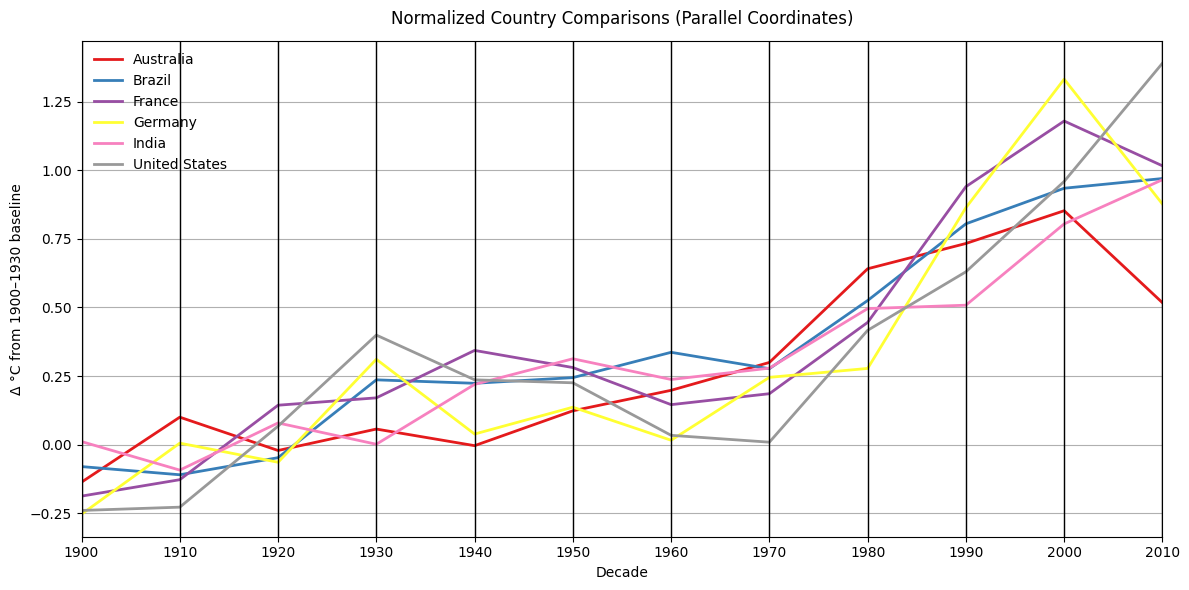

In [42]:
#INSIGHT 6: Solution view only (parallel coordinates)
# select sample countries
countries = ["Germany", "France", "United States", "India", "Brazil", "Australia"]

# compute decadal averages normalized to each baseline (1900–1930)
df6 = df.copy()
df6["decade"] = (df6["year"] // 10) * 10
decadal = df6.groupby(["country","decade"])["avg_temp_c"].mean().reset_index()

# normalize per country
baseline = decadal[(decadal["decade"]>=1900)&(decadal["decade"]<=1930)].groupby("country")["avg_temp_c"].mean()
decadal["anom"] = decadal.apply(lambda r: r["avg_temp_c"] - baseline.get(r["country"], np.nan), axis=1)

# keep only chosen countries
decadal_sub = decadal[decadal["country"].isin(countries)]

# pivot for parallel coords
pivot = decadal_sub.pivot(index="country", columns="decade", values="anom").dropna()

# plot
fig, ax = plt.subplots(figsize=(12,6))
parallel_coordinates(pivot.reset_index(), "country", colormap="Set1", linewidth=2)

ax.set_title("Normalized Country Comparisons (Parallel Coordinates)", pad=12)
ax.set_xlabel("Decade")
ax.set_ylabel("Δ °C from 1900–1930 baseline")
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

This begins by selecting six representative countries and calculating their average land temperatures for each decade, then it normalizes these values by subtracting each country’s 1900–1930 baseline to ensure fair comparisons across naturally hotter or colder regions; after reshaping the data into a format suitable for plotting, it generates a parallel coordinates chart where each colored line represents one country’s warming path over time, clearly showing that although the slopes differ in steepness, all the lines curve upward, emphasizing the shared global warming trajectory.


# Insight 7: Shifting Distributions and Variability

This insight shows that global land temperatures have not only trended upward on average but also become more variable, as seen in a chart where shaded bands track the yearly minimum–maximum range, a bold mean line highlights the steady rise, and jittered sample points illustrate the spread of observations; together, they reveal that even the coldest years today are warmer than many of the warmest years in the early 20th century, meaning the entire distribution has shifted into a hotter climate regime that policymakers and businesses must prepare for.


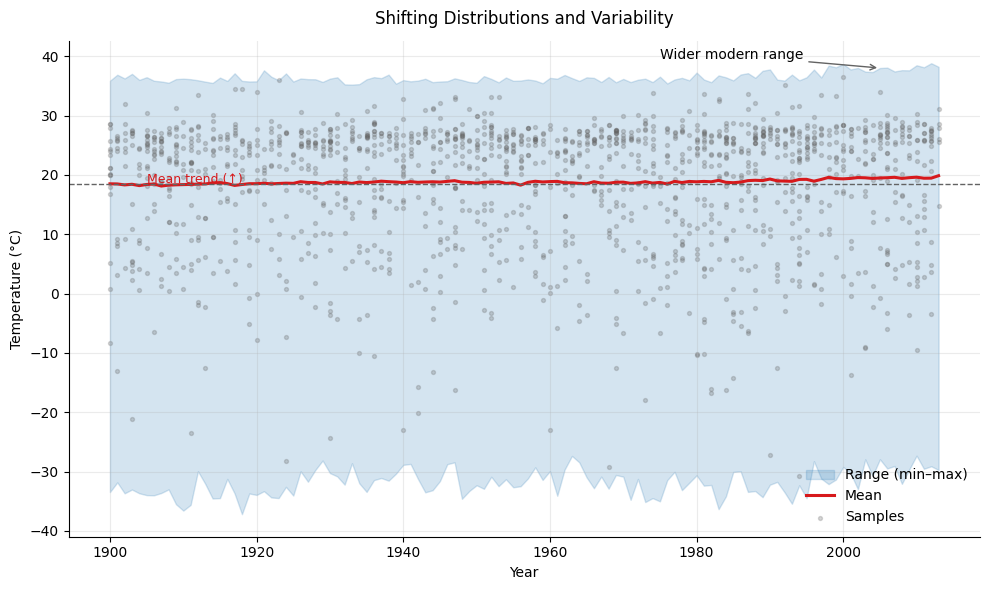

In [35]:
# INSIGHT 7: Distribution of Global Land Temperatures Over Time

# annual aggregates
annual = df.groupby("year")["avg_temp_c"].agg(["min","max","mean"]).reset_index()

# sample for jitter points
samp = df.sample(min(1500, len(df)), random_state=7)

fig, ax = plt.subplots(figsize=(10,6))

# range shading (min–max)
ax.fill_between(annual["year"], annual["min"], annual["max"],
                color=COL_COOL, alpha=0.2, label="Range (min–max)")

# mean line
ax.plot(annual["year"], annual["mean"], lw=2.2, color=COL_WARM, label="Mean")

# jittered samples
ax.scatter(samp["year"], samp["avg_temp_c"], s=8, alpha=0.25,
           color=COL_NEUT, label="Samples")

# annotations
ax.axhline(annual["mean"].iloc[:30].mean(), color=COL_NEUT, ls="--", lw=1)
ax.text(annual["year"].min()+5, annual["mean"].iloc[10]+0.3,
        "Mean trend (↑)", color=COL_WARM, fontsize=9)

ax.annotate("Wider modern range",
            xy=(2005, annual.query("year==2005")["max"].values[0]),
            xytext=(1975, annual["max"].max()+0.7),
            arrowprops=dict(arrowstyle="->", color=COL_NEUT))

# cosmetics
ax.set_title("Shifting Distributions and Variability", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False)
for sp in ("top","right"): ax.spines[sp].set_visible(False)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

This takes global land temperatures grouped by year and plots the full range from minimum to maximum as a shaded band, the yearly mean as a clear red line, and random sample points as gray dots to show distribution density; together, this lets us see not only that average temperatures are rising but also that modern decades show a wider spread, highlighted by annotations pointing out both the upward mean trend and the increased variability compared to earlier records.


#Insight 8: Country–Year Temperature Heatmap



Just Like a barcode of history,this insight explains that by narrowing the analysis to the 15 countries with the most complete records, the heatmap avoids clutter while still telling the global story; each row represents a country, each column a year, and the blue-to-red shading shows how averages have shifted from cooler to hotter across time, making it clear that despite different absolute temperatures, the universal direction is upward and every well-measured country demonstrates the same warming trend,while highlighting which countries have the most reliable records for decision-making.



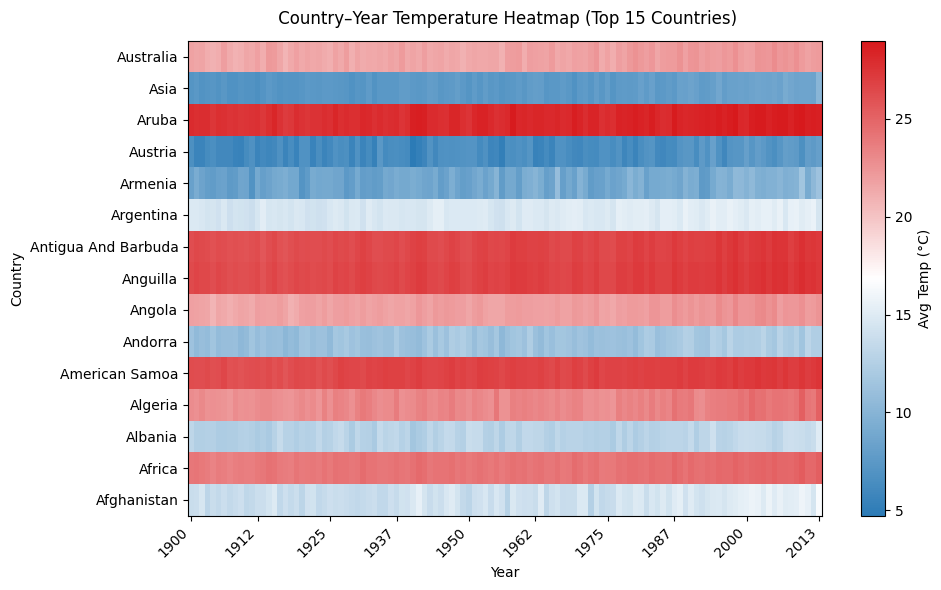

In [37]:
# INSIGHT 8:  Country–Year Temperature Heatmap

pv = df.groupby(["year","country"])["avg_temp_c"].mean().unstack("country")
years = pv.index.values
x_edges = np.concatenate(([years[0]-0.5], (years[:-1]+years[1:])/2, [years[-1]+0.5]))

# Top 15 countries by coverage
top = df.groupby("country")["year"].nunique().sort_values(ascending=False).head(15).index
pv = pv[top]

# category positions
countries = pv.columns.tolist()
m, n = len(countries), len(years)
y_edges = np.arange(m+1)
Z = pv.T.values

from matplotlib.colors import LinearSegmentedColormap
cmap_custom = LinearSegmentedColormap.from_list("custom_coolwarm",
                                                [COL_COOL, "white", COL_WARM])

fig, ax = plt.subplots(figsize=(10,6))
pcm = ax.pcolormesh(x_edges, y_edges, Z, shading="auto", cmap=cmap_custom)

ax.set_title(" Country–Year Temperature Heatmap (Top 15 Countries)", pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Country")

# axis ticks
xticks = np.linspace(years.min(), years.max(), 10, dtype=int)
ax.set_xticks(xticks)
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.set_yticks(np.arange(m)+0.5)
ax.set_yticklabels(countries)

# colorbar
fig.colorbar(pcm, ax=ax, label="Avg Temp (°C)")

plt.tight_layout()
plt.show()

This first aggregates average land temperatures by year and country, then keeps only the top 15 countries with the most complete records to ensure reliable comparison; it prepares edges for the grid, reshapes the country–year data into a matrix, and defines a custom diverging colormap ranging from blue (cool) to red (warm); finally, it uses pcolormesh to plot a heatmap where each row represents a country, each column a year, and the color intensity shows average temperature, with labeled axes and a colorbar making the long-term warming pattern across countries visually clear.


Think of this heatmap as the world’s temperature tapestry. Each of those tells us how warm it was. Reading left to right, you move through time; reading top to bottom, you compare across nations. The cooler shades dominate in the early decades, but as you move toward the right edge of the chart, the colors shift warmer across almost every row. That broad, collective shift shows that rising temperatures aren’t isolated to one country or one region, it’s a global pattern. By focusing on the countries with the best coverage, we can see a consistent signal and planet’s climate palette has changed from cooler tones to hotter ones within just over a century

# Final Discussion and Conclusion

# Summary

This analysis of global land temperature data (1850–2013) produced eight clear insights that tell a connected story about climate change. We found that global warming is undeniable, with a sharp acceleration since 1950. Warming occurs in every month of the year, not just in summers, and some regions are clear hotspots experiencing faster changes than others. Measurement uncertainty has declined over time, so modern records are more reliable than early ones. Recent decades show both accelerated warming and divergent country trajectories, but all bend upward when normalized to their own baselines. Most importantly, the entire distribution of temperatures has shifted upward—minimums, means, and maximums are all hotter than the past. A simplified heatmap across the top 15 countries confirms this pattern is global, not isolated.

For decision-makers, the implications are clear: climate change is widespread, accelerating, and uneven. Businesses, governments, and communities must plan region-specific adaptation strategies while relying on modern, reliable data. Energy demand, agriculture, infrastructure, and long-term investments must all factor in a hotter baseline and greater variability. In short, climate risk is no longer a distant concern—it is a present and measurable shift that demands action.

## Strengths of the EDA Pipeline
- The pipeline transformed a raw historical dataset into a **coherent story told through 8 insights**.  
- Each visual was carefully redesigned to avoid clutter, use **preattentive cues**, and maintain **visual consistency**.  
- The sequence of insights followed a clear narrative arc: from global trends, to seasonal and regional breakdowns, to data reliability, acceleration, comparisons, distribution shifts, and finally a broad global confirmation.  
- We integrates **Uncertainty awareness**,ensuring credibility in early historical records.  



## Limitations
- **Data gaps and naming inconsistencies** (e.g., historical vs. modern country boundaries) may introduce noise.  
- Dataset ends in **2013**, so the last decade of warming is not captured.  
- The analysis shows **patterns, not causes** — external factors like greenhouse gas emissions are not modeled here.  



## Key Insights and Implications
1. **Global warming trend is undeniable**, with shape acceleration Since 1950.
2. **Seasonality has shifted upward** all months are now warmer than the past baseline.
3. **Hotspots exist** some regions/countries warm much faster than others.  
4. **Data reliability has improved**, making modern records more trustworthy.  
5. **The pace of warming has accelerated**, especially post-1950.  
6. **Country trajectories differ**, but all bend upward when normalized to baselines.  
7. **Entire distributions have shifted hotter** not just averages but minimums and maximums too.  
8. **Simplified heatmap confirms global scope**  every country with strong records shows warming.  



##Implications for business and policy:
- **Adaptation strategies must be region-specific**, since warming is uneven.  
- **Energy, agriculture, and infrastructure sectors** must plan for hotter baselines year-round.  
- **Risk management and scenario planning** should rely on modern, more reliable data while acknowledging uncertainty in early records.  



## Data-Driven Recommendations
- **Monitor regional hotspots** for climate risk in supply chains and investments.  
- **Integrate external datasets** (CO₂ emissions, agriculture yields, energy demand) for deeper causal analysis.  
- **Scenario modeling**: extend historical insights into **forecasting tools** for planning.  
- **Sector strategies**:  
  - Energy → prepare for **higher cooling demand** in hot regions.  
  - Agriculture → adapt to **shifting climate zones**.  
  - Real estate/infrastructure → factor **long-term exposure** into planning.  
